In [1]:
# Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Load the Parkinson's Telemonitoring dataset
# renamed parkinsons_updrs.data to parkinsons_telemonitoring.csv
df = pd.read_csv("../data/raw/parkinsons_telemonitoring.csv")
print(df.shape)
df.head()

(5875, 22)


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [3]:
# Check that dataset has loaded properly. 
# Sanity check with official documents. 
print("Shape:", df.shape)
print("Unique subjects:", df["subject#"].nunique())
print()
print("Sex counts (by unique subject):")
print(df.groupby("sex")["subject#"].nunique())
print()
print("Age range:", df["age"].min(), "-", df["age"].max())
print()
print("Missing values per column:")
print(df.isna().sum().sum(), "total missing values")

# Everything appears to be the same as offical documentation.

Shape: (5875, 22)
Unique subjects: 42

Sex counts (by unique subject):
sex
0    28
1    14
Name: subject#, dtype: int64

Age range: 36 - 85

Missing values per column:
0 total missing values


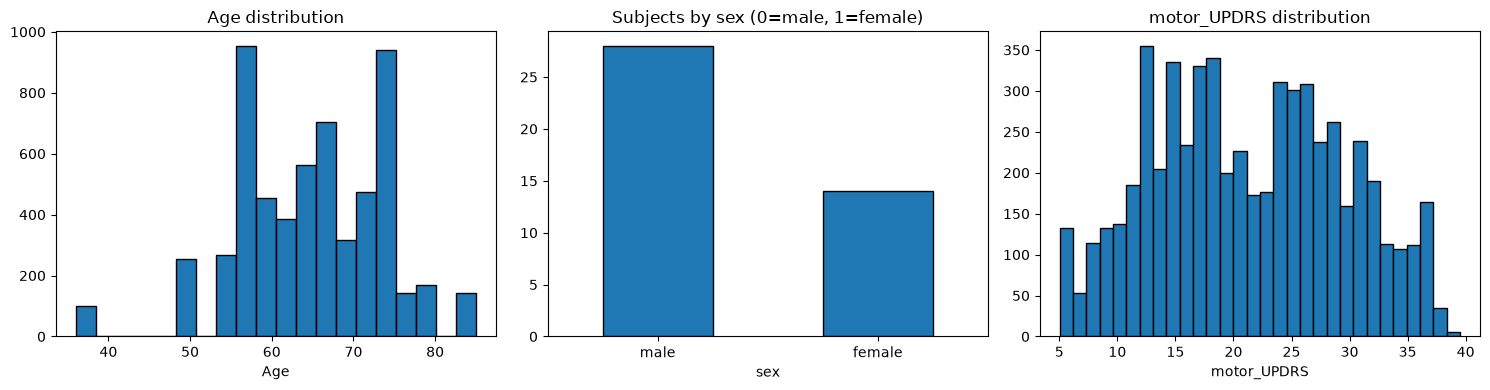

Recordings per subject:
count     42.000000
mean     139.880952
std       15.542550
min      101.000000
25%      130.000000
50%      141.000000
75%      149.750000
max      168.000000
dtype: float64


In [4]:
# Visualising the distribution oof key variables.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["age"], bins=20, edgecolor="black")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")

df.groupby("sex")["subject#"].nunique().plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Subjects by sex (0=male, 1=female)")
axes[1].set_xticklabels(["male", "female"], rotation=0)

axes[2].hist(df["motor_UPDRS"], bins=30, edgecolor="black")
axes[2].set_title("motor_UPDRS distribution")
axes[2].set_xlabel("motor_UPDRS")

plt.tight_layout()
plt.show()

print("Recordings per subject:")
print(df.groupby("subject#").size().describe())

**Observations:**
- AGE: sharp peaks around mid-50s and mid 70s.
    - Each subject contributes to multiple recordings over a 6 month period. So, age barely changes and a spike essentially is one or two subjects.
    - Confimration of rows not being independent observations.
    - subject-grouped train/test split.

- SEX: 28 males to 14 females (2:1 split)
    - limitatation: female has half the data to estimate from. So density estimates are noisier than the male density estimates.

- UPDRS: spanning 5-40 with a soft peak around 12-20.

- RECORDING P/SUBJECT: mean ~140, std ~15.5
    - data is fairly distributed across subjects. 

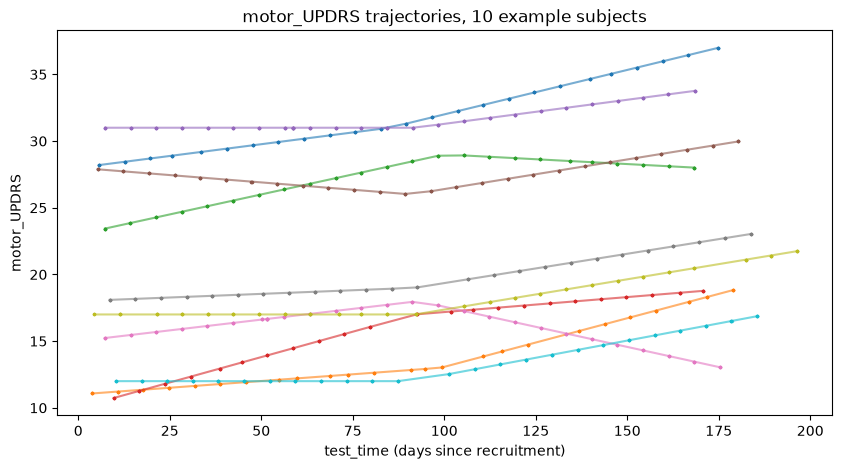

In [5]:
# Visualisation of progression of motor_UPDRS over time for a few subjects.
fig, ax = plt.subplots(figsize=(10, 5))
for subj in df["subject#"].unique()[:10]:  # first 10 subjects, to keep it readable
    sub = df[df["subject#"] == subj].sort_values("test_time")
    ax.plot(sub["test_time"], sub["motor_UPDRS"], alpha=0.6, marker=".", markersize=3)
ax.set_xlabel("test_time (days since recruitment)")
ax.set_ylabel("motor_UPDRS")
ax.set_title("motor_UPDRS trajectories, 10 example subjects")
plt.show()

**Observations:**
- PROGRESSION: most trajectories trend upward over ~6 months.
    - confirms progression is real/measurable in this dataset, not just an assumption from the RQ.

- RATE AND STARTING POINT vary enormously between subjects.
    - one subject: steady climb 28 -> 37. another: nearly flat ~31 the whole period. others start as low as 11-17, only creep up a few points.
    - explains poor R^2 in the benchmark - voice features alone can't capture each subject's own baseline severity + progression rate.
    - two subjects with similar voice measurements could be at very different points on very different trajectories.

- NOT STRICTLY MONOTONIC for every subject (e.g. pink/magenta dips after initial rise, cyan flat-then-rising-then-flat).
    - "progression" language should be phrased as true on average/mostly, not universally.

- supports judging associational vs causal comparison on relative degradation (matched vs shifted), not absolute R^2.

In [6]:
# Correlation of age with each voice feature and with the target
feature_cols = ["Jitter(%)", "Jitter(Abs)", "Jitter:RAP", "Jitter:PPQ5", "Jitter:DDP",
                "Shimmer", "Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5", "Shimmer:APQ11",
                "Shimmer:DDA", "NHR", "HNR", "RPDE", "DFA", "PPE"]

age_corr = df[feature_cols + ["motor_UPDRS"]].corrwith(df["age"]).sort_values()
print("Correlation with age:")
print(age_corr)

print("\nMean motor_UPDRS by sex:")
print(df.groupby("sex")["motor_UPDRS"].mean())

print("\nMean of each voice feature by sex (top 3 largest sex differences):")
sex_diff = df.groupby("sex")[feature_cols].mean().diff().iloc[-1].abs().sort_values(ascending=False)
print(sex_diff.head(3))

Correlation with age:
HNR             -0.104842
DFA             -0.092870
NHR              0.007093
Jitter:RAP       0.010255
Jitter:DDP       0.010258
Jitter:PPQ5      0.013199
Jitter(%)        0.023071
Jitter(Abs)      0.035691
Shimmer:APQ5     0.089983
RPDE             0.090208
Shimmer:APQ3     0.098912
Shimmer:DDA      0.098913
Shimmer          0.101554
Shimmer(dB)      0.111130
PPE              0.120790
Shimmer:APQ11    0.135238
motor_UPDRS      0.273665
dtype: float64

Mean motor_UPDRS by sex:
sex
0    21.469349
1    20.924581
Name: motor_UPDRS, dtype: float64

Mean of each voice feature by sex (top 3 largest sex differences):
RPDE           0.034539
Shimmer(dB)    0.027928
DFA            0.025141
Name: 1, dtype: float64


**Observations:**
- AGE -> motor_UPDRS: r = 0.27
    - Older subjects in this smaple tend to have higher motor UPDRS scores.
    - Supports age as a confounder.

- AGE -> voice features: most r < 0.15
    - Age is a genuine confounder. 
    - Stronger on the Y (UPDRS) side. than the X (voice) side.

- SEX -> motor_UPDRS: 21.47 (male) vs. 20.92 (female)
    - A gap of ~0.55. Relatively small to teh 5-40 range
    - Weaker evidence than age

- SEX -> voice features:
    - largest differences (RPDE, Shimmer(dB),DFA) are ~0.025-0.035
    - Sex's confounding role is more supported by prior literature than by strong signla in this specific sample.

OVERALL: age carries more of the confounding weight than sex here.


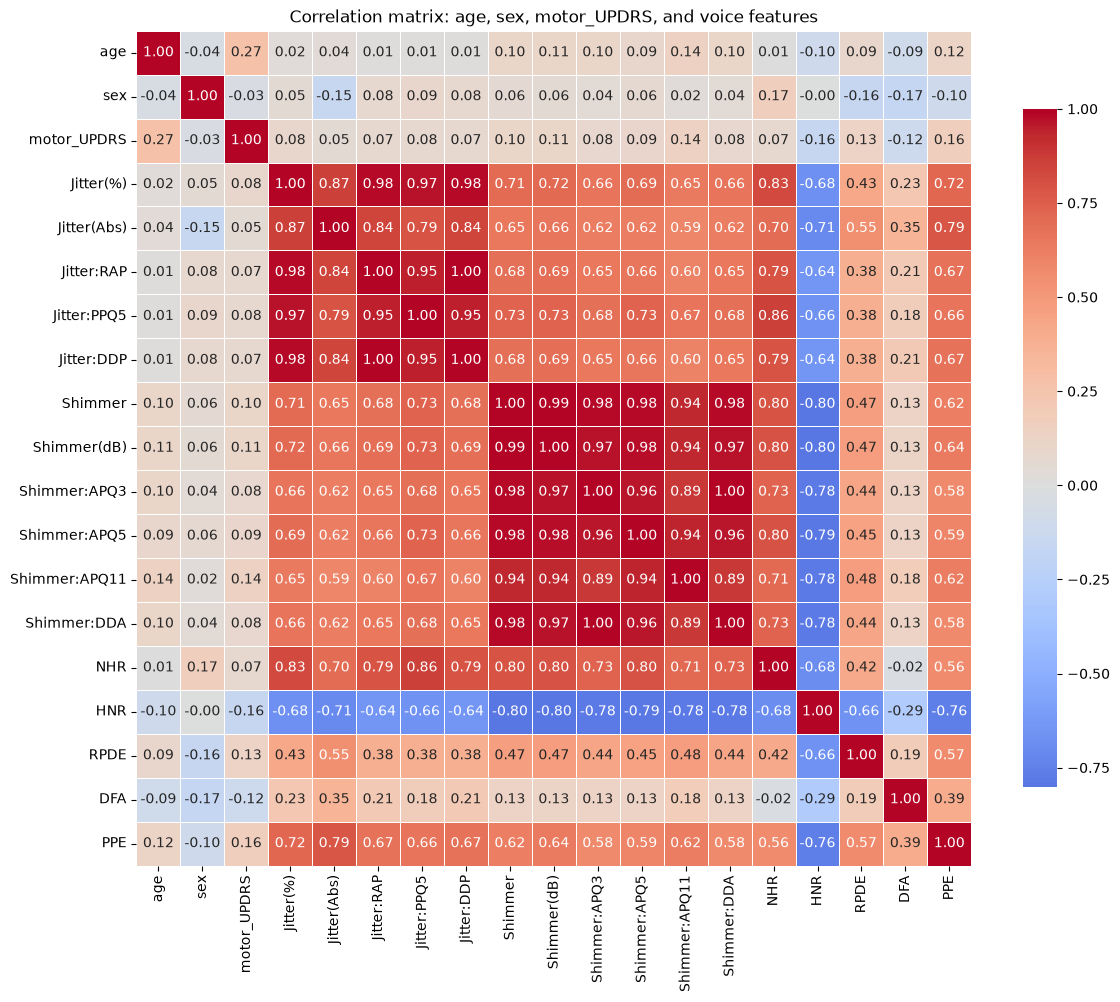

In [7]:
corr_cols = ["age", "sex", "motor_UPDRS"] + feature_cols
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title("Correlation matrix: age, sex, motor_UPDRS, and voice features")
plt.tight_layout()
plt.show()

**Observations:**
- JITTER: Jitter(%), Jitter:RAP, Jitter:PPq5, Jitter:DDP all correlate ~0.95-1.00 with each other.
- SHIMMER: Shimmer, Shommer(dB), Shimmer:APQ3, Shimmer:APQ5, Shimmer:APQ11, Shimmer:DDA all correlate ~0.89-1.00 with each other.

Makes sense as these are several mathematical formulations of the same two underlying phenomena.

- 16 features are more close to 3-4 independent pieces of information (jitter, shimmer, NHR/HNR, nonlinear)
- motor_UPDRS has weak correlations with voice features (0.05-0.16) therefore, we can expect that voice features alone may struggle to predict UPDRS.

In [ ]:
# Verify the "fixed constant" claim: are DDP/RAP and DDA/APQ3 exactly 3, by definition?
ratio_jitter = df["Jitter:DDP"] / df["Jitter:RAP"]
ratio_shimmer = df["Shimmer:DDA"] / df["Shimmer:APQ3"]

print("Jitter:DDP / Jitter:RAP ratio:")
print(ratio_jitter.describe())
print()
print("Shimmer:DDA / Shimmer:APQ3 ratio:")
print(ratio_shimmer.describe())

**Observations:**
- Both ratios are exactly 3.0 (mean 3.0000, negligible standard deviation, floating-point
  noise only), confirming these pairs are related by a fixed mathematical constant
  (DDP = 3×RAP, DDA = 3×APQ3 by definition), not merely empirically similar.
- This validates that these correlations reflect genuine
  mathematical redundancy in the feature set, rather than a coincidental relationship.

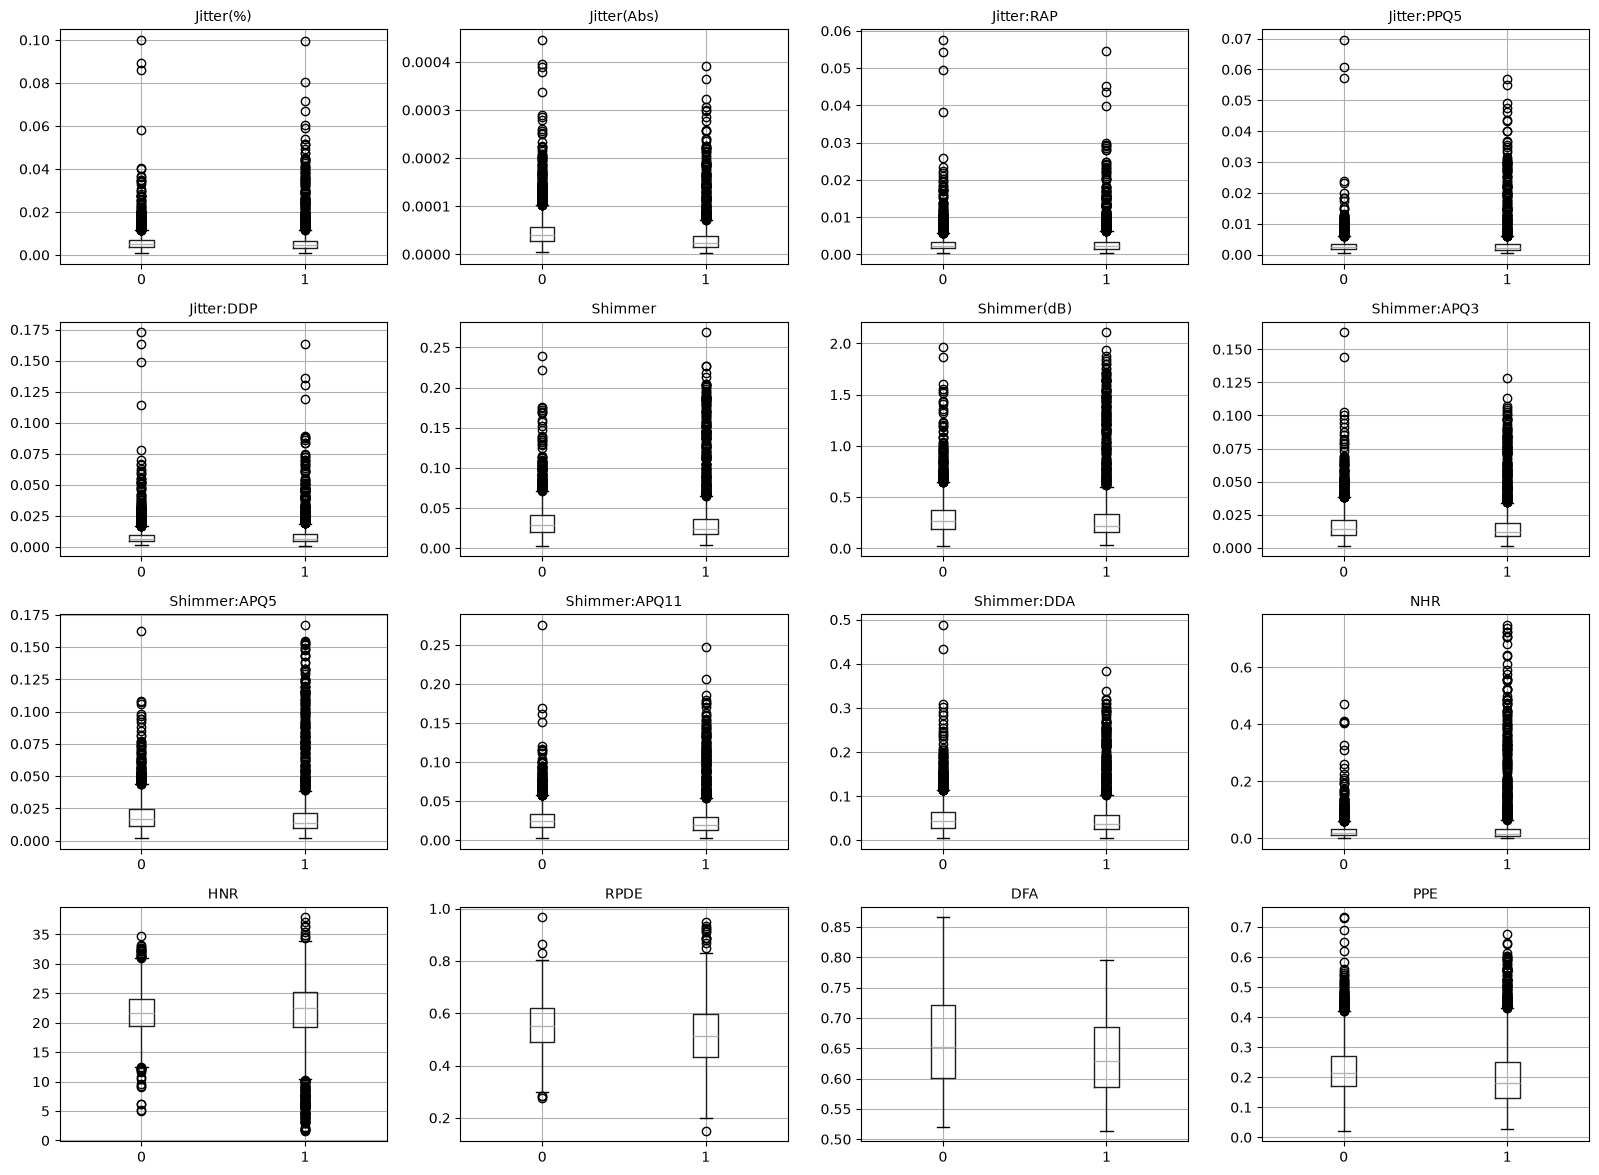

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.flat, feature_cols):
    df.boxplot(column=col, by="sex", ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Observations:**
- SEX DIFFERENCES: mostly small and consistent with earlier correlations.
    - DFA is the clearest exception: male median (~0.65) noticeably higher than female (~0.63).
    - RPDE shows a similar, subtler downward shift for females.

- JITTER/SHIMMER/NHR: heavy right-skew, extreme outlier tails.
    - IQR box squeezed near zero, long tail of outliers 10-20x the box height.
    - likely recordings from patients with more advanced symptoms.
    - means from earlier correlations are being influenced by these outliers.
    - Gaussian KDE assumption (for bootstrap) on a skewed variable - limitation to note.

- RPDE/HNR/DFA/PPE: comparatively well-behaved.
    - fewer/less extreme outliers, closer to symmetric.
    - makes sense: nonlinear dynamical measures, normalized/bounded by construction.

- Not directly relevant to Y (motor_UPDRS isn't skewed), but relevant to X side if features were ever used as bootstrap targets.

Median subject age: 65.0
Younger group: 19 subjects, age range 36.0-63.0
Older group: 23 subjects, age range 65.0-85.0


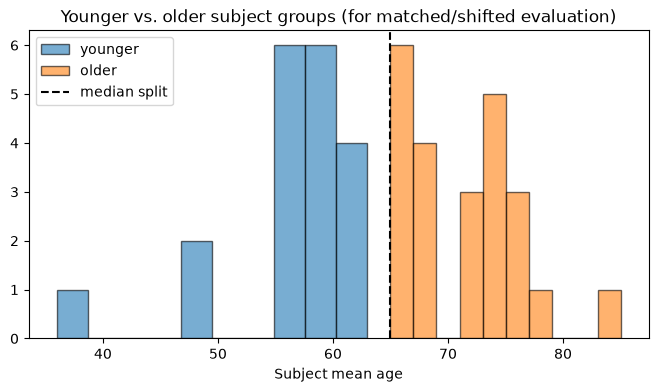


Sex balance in each group:
Younger: {0: 12, 1: 7}
Older: {0: 16, 1: 7}


In [9]:
subj_age = df.groupby("subject#")["age"].mean()
median_age = subj_age.median()
younger = subj_age[subj_age < median_age].index
older = subj_age[subj_age >= median_age].index

print(f"Median subject age: {median_age}")
print(f"Younger group: {len(younger)} subjects, age range {subj_age[younger].min()}-{subj_age[younger].max()}")
print(f"Older group: {len(older)} subjects, age range {subj_age[older].min()}-{subj_age[older].max()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(subj_age[younger], bins=10, alpha=0.6, label="younger", edgecolor="black")
ax.hist(subj_age[older], bins=10, alpha=0.6, label="older", edgecolor="black")
ax.axvline(median_age, color="black", linestyle="--", label="median split")
ax.set_xlabel("Subject mean age")
ax.legend()
ax.set_title("Younger vs. older subject groups (for matched/shifted evaluation)")
plt.show()

print("\nSex balance in each group:")
print("Younger:", df[df['subject#'].isin(younger)].groupby('sex')['subject#'].nunique().to_dict())
print("Older:", df[df['subject#'].isin(older)].groupby('sex')['subject#'].nunique().to_dict())

In [ ]:
import sys
sys.path.append("..")

In [13]:

from src.simultaneous_sex_association import simultaneous_sex_association
import warnings
warnings.filterwarnings("ignore", category=Warning, module="statsmodels")

df = pd.read_csv("../data/raw/parkinsons_telemonitoring.csv")
results = simultaneous_sex_association(df)
print(results.to_string(index=False))
print(f"\n{results['significant'].sum()} / {len(results)} features show a significant sex association (p<0.05).")

      feature  sex_coef   sex_se    sex_p    ci_low  ci_high  significant
  Jitter(Abs) -0.000013 0.000008 0.116051 -0.000028 0.000003        False
         RPDE -0.036918 0.024557 0.132746 -0.085048 0.011213        False
          DFA -0.028100 0.020505 0.170566 -0.068290 0.012089        False
          NHR  0.021089 0.015651 0.177855 -0.009588 0.051765        False
          PPE -0.021436 0.021942 0.328611 -0.064442 0.021570        False
  Jitter:PPQ5  0.000657 0.000801 0.412044 -0.000913 0.002228        False
   Jitter:RAP  0.000452 0.000563 0.422536 -0.000652 0.001555        False
   Jitter:DDP  0.001354 0.001689 0.422664 -0.001956 0.004665        False
 Shimmer:APQ5  0.002321 0.004453 0.602197 -0.006407 0.011049        False
      Shimmer  0.003251 0.006792 0.632189 -0.010060 0.016562        False
  Shimmer(dB)  0.028264 0.060432 0.640001 -0.090180 0.146708        False
    Jitter(%)  0.000515 0.001119 0.645289 -0.001678 0.002709        False
  Shimmer:DDA  0.003770 0.009792 0.700

In [14]:
import sys
sys.path.append("..")
from src.simultaneous_age_association import simultaneous_age_association


results_age = simultaneous_age_association(df)
print(results_age.to_string(index=False))
print(f"\n{results_age['significant'].sum()} / {len(results_age)} features show a significant age association (p<0.05).")

      feature      age_coef       age_se    age_p        ci_low      ci_high  significant
Shimmer:APQ11  3.796277e-04 2.661609e-04 0.153779 -1.420380e-04 9.012934e-04        False
          PPE  1.374104e-03 1.136771e-03 0.226748 -8.539261e-04 3.602133e-03        False
  Shimmer:DDA  6.018403e-04 5.072536e-04 0.235437 -3.923586e-04 1.596039e-03        False
 Shimmer:APQ3  2.006103e-04 1.690851e-04 0.235446 -1.307904e-04 5.320110e-04        False
  Shimmer(dB)  3.706573e-03 3.128267e-03 0.236071 -2.424718e-03 9.837863e-03        False
          HNR -7.038169e-02 6.165411e-02 0.253638 -1.912215e-01 5.045815e-02        False
      Shimmer  3.948712e-04 3.515668e-04 0.261363 -2.941871e-04 1.083929e-03        False
 Shimmer:APQ5  2.411636e-04 2.304802e-04 0.295398 -2.105692e-04 6.928965e-04        False
         RPDE  1.254766e-03 1.272088e-03 0.323945 -1.238480e-03 3.748012e-03        False
          DFA -5.010313e-04 1.059997e-03 0.636447 -2.578588e-03 1.576525e-03        False
  Jitter(A